# TASK 01

In [2]:
#create a array of random integers to simulate sales data for 4 products over 30 days and 3 regions
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
sales = rng.integers(50, 500, size=(4, 30, 3))

print("sales shape:", sales.shape)
print(sales)

sales shape: (4, 30, 3)
[[[ 90 398 344]
  [247 244 436]
  [ 88 363 140]
  [ 92 286 489]
  [381 392 372]
  [403 280 107]
  [427 252 275]
  [216 132 467]
  [401 339 231]
  [420 295 249]
  [252 152  91]
  [299 449  78]
  [436 422 174]
  [334 124 391]
  [365 209  80]
  [486 250 451]
  [355 400 391]
  [137 213 260]
  [274  69 295]
  [119 384 357]
  [465 385 214]
  [485 234 196]
  [457 216  84]
  [261 408 135]
  [258 108 358]
  [264 198 152]
  [304 351 473]
  [246 122 424]
  [333 365  93]
  [190 395 424]]

 [[245 412 428]
  [224 454 179]
  [157 357 336]
  [112 424 139]
  [412  53 408]
  [404 401 349]
  [262 367 174]
  [401 300 256]
  [277 305  66]
  [112 160 101]
  [247 350 344]
  [261 434 304]
  [ 85 394 308]
  [335 304 299]
  [ 90 301 407]
  [186 321  63]
  [206 246 492]
  [146 174 233]
  [496 434  65]
  [155 419  76]
  [435 176 462]
  [182 245 347]
  [106 300 277]
  [402 498 348]
  [234 232 238]
  [416 194 125]
  [200  60  97]
  [ 90 397 375]
  [363 257 372]
  [122 455 275]]

 [[472 118 2

In [ ]:
#Total sales per shop 
per_shop = sales.sum(axis=(1, 2))
print("Total sales per shop:", per_shop)
print("Shape:", per_shop.shape)

Total sales per shop: [25751 24730 24062 24356]
Shape: (4,)


In [ ]:
#Average daily sales per category
avg_per_category = sales.mean(axis=(0, 1))
print("Average sales per category:", avg_per_category)
print("Shape:", avg_per_category.shape)

Average sales per category: [274.625      277.76666667 271.76666667]
Shape: (3,)


In [ ]:
#Best day for each shop
daily_totals = sales.sum(axis=2)
print("Daily totals:")
print(daily_totals)
print("Shape:", daily_totals.shape)

Daily totals:
[[ 832  927  591  867 1145  790  954  815  971  964  495  826 1032  849
   654 1187 1146  610  638  860 1064  915  757  804  724  614 1128  792
   791 1009]
 [1085  857  850  675  873 1154  803  957  648  373  941  999  787  938
   798  570  944  553  995  650 1073  774  683 1248  704  735  357  862
   992  852]
 [ 863  886  502  875 1016  396  898 1094  817 1054  944  805  429  818
   881  910  683  884  992  764  517  761 1031  470  679  565  849  776
  1057  846]
 [ 360  986  741  529  870  901  970  848 1011  484  688  860  676  799
   438 1101 1061  886  797  478  701 1093  816  993 1067 1132  544  499
  1100  927]]
Shape: (4, 30)


In [ ]:
#highest total for each shop:
best_day = np.argmax(daily_totals, axis=1)
print("Best day for each shop:", best_day)
print("Shape:", best_day.shape)

Best day for each shop: [15 23  7 25]
Shape: (4,)


In [ ]:
#most consistent shop
daily_std = daily_totals.std(axis=1)
print("Daily standard deviation:", daily_std)
print("Shape:", daily_std.shape)

Daily standard deviation: [177.53543934 205.11303117 191.27239448 223.6727868 ]
Shape: (4,)


In [ ]:
#the shop with the smallest standard deviation:
most_consistent_shop = np.argmin(daily_std)
print("Most consistent shop:", most_consistent_shop)
print("Standard deviation:", daily_std[most_consistent_shop])

Most consistent shop: 0
Standard deviation: 177.53543934162053


In [ ]:
#calculate the mean for every shop:
shop_mean = sales.mean(axis=(1, 2), keepdims=True)
print("Shop mean shape:", shop_mean.shape)

Shop mean shape: (4, 1, 1)


In [ ]:
mean_centered = sales - shop_mean
print("Original shape:", sales.shape)
print("Shop mean shape:", shop_mean.shape)
print("Mean-centered shape:", mean_centered.shape)

Original shape: (4, 30, 3)
Shop mean shape: (4, 1, 1)
Mean-centered shape: (4, 30, 3)


# Task-2

In [ ]:
#Convert equations into matrices
A = np.array([
    [2.,  3., -1.],
    [4., -1.,  2.],
    [-1., 2.,  3.]
])

b = np.array([5., 6., 7.])

In [ ]:
#Use np.linalg.solve()
x = np.linalg.solve(A, b)
print("Solution:", x)

Solution: [1.04761905 1.52380952 1.66666667]


In [ ]:
#Verify the solution
result = A @ x

print("A @ x:", result)
print("b:", b)
print("Verified:", np.allclose(A @ x, b))

A @ x: [5. 6. 7.]
b: [5. 6. 7.]
Verified: True


In [ ]:
#Solve using inverse
A_inv = np.linalg.inv(A)
x_inv = A_inv @ b

print("Solution using inverse:", x_inv)

Solution using inverse: [1.04761905 1.52380952 1.66666667]


In [ ]:
#Time both approaches
import time
rng = np.random.default_rng(42)

A_large = rng.random((500, 500))
b_large = rng.random(500)

In [ ]:
#Time solve()
start = time.perf_counter()
x_solve = np.linalg.solve(A_large, b_large)
solve_time = time.perf_counter() - start

print("solve() time:", solve_time)

solve() time: 0.17343399999663234


In [ ]:
#Time inverse approach
start = time.perf_counter()
x_inv_large = np.linalg.inv(A_large) @ b_large
inv_time = time.perf_counter() - start

print("inv() @ b time:", inv_time)

inv() @ b time: 0.03841779998037964


In [ ]:
#Compare
ratio = inv_time / solve_time

print("Ratio (inv / solve):", ratio)

Ratio (inv / solve): 0.22151250608949583


In [ ]:
#Create a singular matrix
A_singular = np.array([
    [1., 2., 3.],
    [2., 4., 6.],
    [4., 5., 6.]
])

b_singular = np.array([6., 12., 15.])

In [ ]:
try:
    x_singular = np.linalg.solve(A_singular, b_singular)
    print(x_singular)
except np.linalg.LinAlgError as e:
    print("Error:", e)

Error: Singular matrix


In [ ]:
print("Determinant:", np.linalg.det(A_singular))

Determinant: 0.0


# Task-3

In [ ]:
def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [ ]:
#Test identical vectors
v = np.array([1., 2., 3.])
result = cosine_similarity(v, v)

print("Identical:", result)
print("Verified:", np.isclose(result, 1.0))

Identical: 1.0
Verified: True


In [ ]:
#Test opposite vectors
v1 = np.array([1., 2., 3.])
v2 = np.array([-1., -2., -3.])
result = cosine_similarity(v1, v2)

print("Opposite:", result)
print("Verified:", np.isclose(result, -1.0))

Opposite: -1.0
Verified: True


In [ ]:
#Test perpendicular vectors
v1 = np.array([1., 0.])
v2 = np.array([0., 1.])
result = cosine_similarity(v1, v2)

print("Perpendicular:", result)
print("Verified:", np.isclose(result, 0.0))

Perpendicular: 0.0
Verified: True


In [ ]:
#100 vectors
rng = np.random.default_rng(42)
M = rng.normal(size=(100, 5))
query = rng.normal(size=5)

print("M shape:", M.shape)
print("query shape:", query.shape)

M shape: (100, 5)
query shape: (5,)


In [ ]:
#Calculate norms of all 100 vectors
norms = np.linalg.norm(M, axis=1, keepdims=True)
print("norms shape:", norms.shape)

norms shape: (100, 1)


In [ ]:
#Normalise the 100 vectors
M_normalized = M / norms
print("M_normalized shape:", M_normalized.shape)

M_normalized shape: (100, 5)


In [ ]:
#Normalise
query_normalized = query / np.linalg.norm(query)
print("query_normalized shape:", query_normalized.shape)

query_normalized shape: (5,)


In [ ]:
#Calculate similarity with ALL vectors
similarities = M_normalized @ query_normalized
print("Similarities shape:", similarities.shape)
print(similarities)

Similarities shape: (100,)
[ 0.34668962  0.1863423  -0.19267237 -0.21903212 -0.04277981 -0.60585218
  0.25020356  0.20375996  0.29215265 -0.0698372   0.60151059 -0.47529622
 -0.77340522  0.07653818 -0.43112517  0.10344913  0.76208875 -0.50953589
  0.88706606 -0.03919505  0.37001567  0.36150576  0.51552274 -0.34327018
 -0.81785103  0.75796146  0.30364944 -0.93541064  0.3368227  -0.6213017
  0.12397129  0.67200003 -0.46390099 -0.0619245   0.72703779  0.14098917
 -0.09589201  0.02739232  0.36905571  0.02955598  0.69191417  0.35728272
  0.26880417  0.44520729  0.26399383  0.27112155 -0.29774678  0.04881554
 -0.33655621 -0.327701    0.0986977   0.94301211 -0.40645941  0.29021213
 -0.81782596 -0.27454349  0.1162332   0.12768295  0.29271057  0.34832234
  0.11043807 -0.92066945 -0.26797552  0.33412258 -0.70651515  0.3607915
  0.589503   -0.8267927  -0.77337147 -0.49262749 -0.41748528  0.56258689
  0.24040145 -0.11165328 -0.32786423  0.25588865  0.83125637  0.40296853
 -0.58614124  0.44317333 -

In [ ]:
#Full 100 × 100 similarity matrix
similarity_matrix = M_normalized @ M_normalized.T
print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (100, 100)


In [ ]:
print(np.diag(similarity_matrix))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [ ]:
print(
    np.allclose(
        np.diag(similarity_matrix),
        1.0
    )
)

True


# Task-4

In [ ]:
#Create make_line()
def make_line(n, slope, intercept, noise, seed=0):
    rng = np.random.default_rng(seed)

    x = np.linspace(0, 10, n)

    y = slope * x + intercept + rng.normal(0, noise, n)

    return x, y

In [ ]:
#Generate three datasets
x1, y1 = make_line(
    n=100,
    slope=3,
    intercept=5,
    noise=0.5,
    seed=42
)

x2, y2 = make_line(
    n=100,
    slope=3,
    intercept=5,
    noise=2.0,
    seed=42
)

x3, y3 = make_line(
    n=100,
    slope=3,
    intercept=5,
    noise=10.0,
    seed=42
)

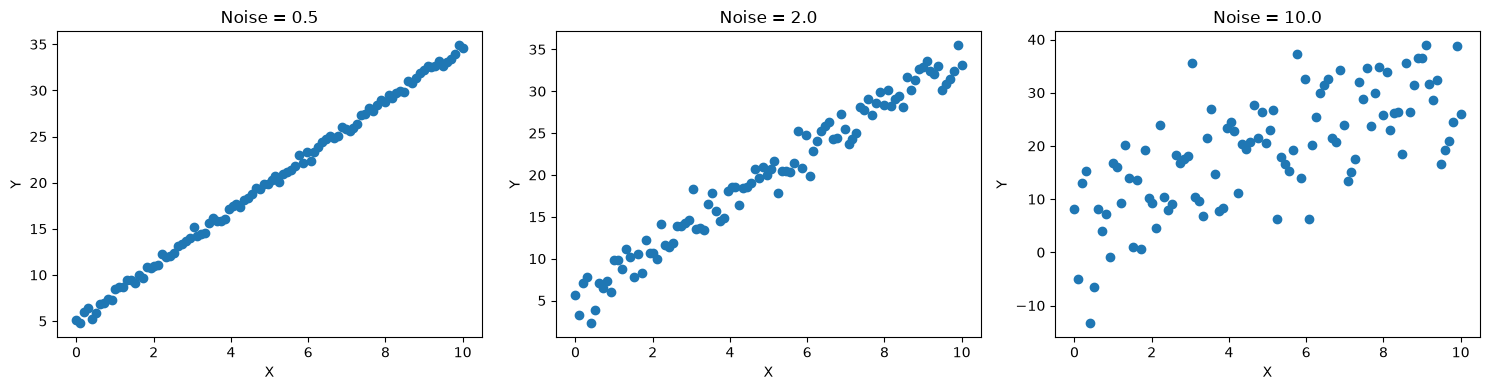

In [ ]:
#Plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x1, y1)
axes[0].set_title("Noise = 0.5")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

axes[1].scatter(x2, y2)
axes[1].set_title("Noise = 2.0")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

axes[2].scatter(x3, y3)
axes[2].set_title("Noise = 10.0")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")

plt.tight_layout()
plt.show()

In [ ]:
#Recover the slope using np.polyfit
slope1, intercept1 = np.polyfit(x1, y1, 1)

print("Noise 0.5")
print("Estimated slope:", slope1)
print("Estimated intercept:", intercept1)

Noise 0.5
Estimated slope: 2.979023581648138
Estimated intercept: 5.079747286017382


In [ ]:
#all three
slope1, intercept1 = np.polyfit(x1, y1, 1)
slope2, intercept2 = np.polyfit(x2, y2, 1)
slope3, intercept3 = np.polyfit(x3, y3, 1)

print("Noise = 0.5")
print("Slope:", slope1)

print("\nNoise = 2.0")
print("Slope:", slope2)

print("\nNoise = 10.0")
print("Slope:", slope3)

Noise = 0.5
Slope: 2.979023581648138

Noise = 2.0
Slope: 2.916094326592552

Noise = 10.0
Slope: 2.5804716329627575


In [ ]:
#Create make_clusters()
def make_clusters(n, centres, spread, seed=0):
    rng = np.random.default_rng(seed)

    centres = np.asarray(centres)

    n_clusters = len(centres)

    points_per_cluster = n // n_clusters

    clusters = []

    for centre in centres:
        points = rng.normal(
            loc=centre,
            scale=spread,
            size=(points_per_cluster, 2)
        )

        clusters.append(points)

    return np.vstack(clusters)


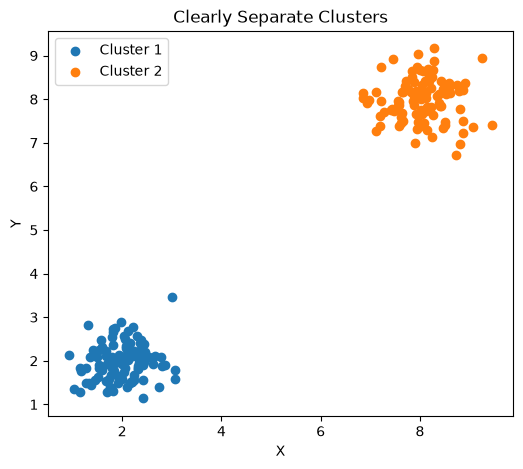

In [ ]:
#Clearly separated clusters
centres = [
    [2, 2],
    [8, 8]
]
separate = make_clusters(
    n=200,
    centres=centres,
    spread=0.5,
    seed=42
)
plt.figure(figsize=(6, 5))

plt.scatter(
    separate[:100, 0],
    separate[:100, 1],
    label="Cluster 1"
)

plt.scatter(
    separate[100:, 0],
    separate[100:, 1],
    label="Cluster 2"
)

plt.title("Clearly Separate Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

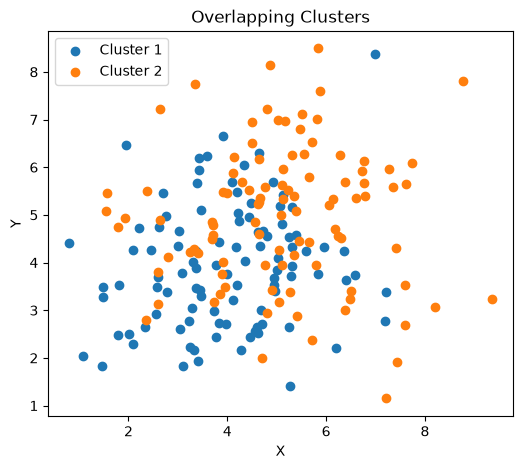

In [ ]:
#Overlapping clusters
centres = [
    [4, 4],
    [5, 5]
]
overlapping = make_clusters(
    n=200,
    centres=centres,
    spread=1.5,
    seed=42
)
plt.figure(figsize=(6, 5))

plt.scatter(
    overlapping[:100, 0],
    overlapping[:100, 1],
    label="Cluster 1"
)

plt.scatter(
    overlapping[100:, 0],
    overlapping[100:, 1],
    label="Cluster 2"
)

plt.title("Overlapping Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


In [ ]:
#Make the cluster function
separate[:100]
separate[100:]
def make_clusters(n, centres, spread, seed=0):
    rng = np.random.default_rng(seed)

    centres = np.asarray(centres)

    n_clusters = len(centres)
    points_per_cluster = n // n_clusters

    clusters = []
    labels = []

    for i, centre in enumerate(centres):
        points = rng.normal(
            loc=centre,
            scale=spread,
            size=(points_per_cluster, 2)
        )

        clusters.append(points)
        labels.append(
            np.full(points_per_cluster, i)
        )

    return np.vstack(clusters), np.concatenate(labels)
points, labels = make_clusters(
    n=200,
    centres=[[2, 2], [8, 8]],
    spread=0.5,
    seed=42
)

print("Points shape:", points.shape)
print("Labels shape:", labels.shape)

Points shape: (200, 2)
Labels shape: (200,)


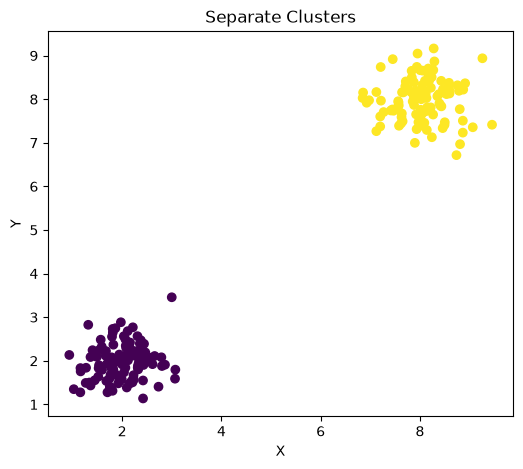

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    points[:, 0],
    points[:, 1],
    c=labels
)

plt.title("Separate Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Task-05

In [ ]:
#Floating-point error: 0.1 + 0.2
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)
print(repr(0.1 + 0.2))

0.30000000000000004
False
0.30000000000000004


In [ ]:
print(np.isclose(0.1 + 0.2, 0.3))

True


In [ ]:
#Find two more decimal values
a = 0.1
b = 0.7

print(a + b)
print(a + b == 0.8)
print(repr(a + b))

0.7999999999999999
False
0.7999999999999999


In [ ]:
#Integer overflow using int8
small = np.array([1, 2, 3], dtype=np.int8)
print(small)
print(small.dtype)

result = small * 100
print(result)
print(result.dtype)

[1 2 3]
int8
[100 -56  44]
int8


In [ ]:
#How can we avoid integer overflow?
large = np.array([1, 2, 3], dtype=np.int64)
print(large * 100)

[100 200 300]


In [ ]:
#Detection
print(np.iinfo(np.int8))

Machine parameters for int8
---------------------------------------------------------------
min = -128
max = 127
---------------------------------------------------------------



In [ ]:
#Avoidance
np.int32

numpy.int32

In [ ]:
#float32 precision loss
x = np.float32(1e8)

print("x:", x)
print("x + 1:", np.float32(x + 1))
print("Difference:", np.float32(x + 1) - x)

x: 1e+08
x + 1: 1e+08
Difference: 0.0


In [2]:
#Catastrophic cancellation
a = np.float32(1e8)
b = np.float32(1e8 - 1)

print("a:", a)
print("b:", b)

print("a - b:", a - b)

a: 1e+08
b: 1e+08
a - b: 0.0


In [3]:
#Compare with float64
a = np.float64(1e8)
b = np.float64(1e8 - 1)

print(a - b)

1.0


In [4]:
#Summing one million small floats
small_values = np.full(
    1_000_000,
    0.1,
    dtype=np.float32
)

In [5]:
#calculate using float32
sum32 = np.sum(
    small_values,
    dtype=np.float32
)

print("float32 sum:", sum32)

float32 sum: 100000.01


In [6]:
#alculate using float64
sum64 = np.sum(
    small_values,
    dtype=np.float64
)

print("float64 sum:", sum64)

float64 sum: 100000.00149011612


In [8]:
#Compare the errors
exact = 100_000.0
print("Exact:", exact)

error32 = abs(sum32 - exact)
error64 = abs(sum64 - exact)

print("float32 error:", error32)
print("float64 error:", error64)

Exact: 100000.0
float32 error: 0.0078125
float64 error: 0.0014901161193847656


# Task-6

In [3]:
#Generate 300 samples with 4 features
rng = np.random.default_rng(42)
n = 300
f1 = rng.normal(0, 1, n)

In [4]:
#strongly correlated with feature 1
f2 = f1 * 0.9 + rng.normal(0, 0.3, n)

In [5]:
# weakly correlated with feature 1
f3 = f1 * 0.2 + rng.normal(0, 1, n)

In [6]:
#independent
f4 = rng.normal(0, 1, n)
X = np.column_stack([f1, f2, f3, f4])
print("Original X shape:", X.shape)


Original X shape: (300, 4)


In [7]:
#Standardise every feature
mean = X.mean(axis=0)
std = X.std(axis=0)

Xs = (X - mean) / std

print("\nStandardised X shape:", Xs.shape)

print("Means:", Xs.mean(axis=0))
print("Standard deviations:", Xs.std(axis=0))

print("\nMean approximately 0:",
      np.allclose(Xs.mean(axis=0), 0))

print("Std approximately 1:",
      np.allclose(Xs.std(axis=0), 1))


Standardised X shape: (300, 4)
Means: [ 1.72084569e-17  7.40148683e-19 -5.92118946e-18  1.48029737e-17]
Standard deviations: [1. 1. 1. 1.]

Mean approximately 0: True
Std approximately 1: True


In [8]:
#Compute covariance matrix by hand
cov_matrix = (Xs.T @ Xs) / (n - 1)

print("\nCovariance matrix:")
print(cov_matrix)

print("\nCovariance matrix shape:", cov_matrix.shape)

print("Shape is 4x4:",
      cov_matrix.shape == (4, 4))

print("Symmetric:",
      np.allclose(cov_matrix, cov_matrix.T))


Covariance matrix:
[[ 1.00334448  0.94407023  0.11046266  0.02645839]
 [ 0.94407023  1.00334448  0.05943294 -0.01137136]
 [ 0.11046266  0.05943294  1.00334448  0.03275312]
 [ 0.02645839 -0.01137136  0.03275312  1.00334448]]

Covariance matrix shape: (4, 4)
Shape is 4x4: True
Symmetric: True


In [9]:
#Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)


Eigenvalues:
[1.96269897 1.02966816 0.96381287 0.05719794]

Eigenvectors:
[[-0.70331381 -0.03224123 -0.05333495  0.70814234]
 [-0.69966124 -0.09515891 -0.07083172 -0.70455788]
 [-0.12485075  0.61902413  0.7744781  -0.03748456]
 [-0.01536628  0.77891875 -0.62635607 -0.02697294]]


In [10]:
# Variance explained by each component
variance_proportion = eigenvalues / eigenvalues.sum()

print("\nVariance proportion:")
for i, proportion in enumerate(variance_proportion, start=1):
    print(f"PC{i}: {proportion:.4f} ({proportion * 100:.2f}%)")


Variance proportion:
PC1: 0.4890 (48.90%)
PC2: 0.2566 (25.66%)
PC3: 0.2402 (24.02%)
PC4: 0.0143 (1.43%)


In [11]:
#Number of components needed for 90% variance
cumulative_variance = np.cumsum(variance_proportion)

print("\nCumulative variance:")
for i, value in enumerate(cumulative_variance, start=1):
    print(f"First {i} component(s): {value:.4f} ({value * 100:.2f}%)")

components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("\nComponents needed for 90% variance:",
      components_90)


Cumulative variance:
First 1 component(s): 0.4890 (48.90%)
First 2 component(s): 0.7456 (74.56%)
First 3 component(s): 0.9857 (98.57%)
First 4 component(s): 1.0000 (100.00%)

Components needed for 90% variance: 3


In [12]:
# Project data onto first two components
X_pca = Xs @ eigenvectors[:, :2]

print("\nPCA projection shape:", X_pca.shape)

print("First 5 projected samples:")
print(X_pca[:5])


PCA projection shape: (300, 2)
First 5 projected samples:
[[-0.99711646  0.58071674]
 [ 1.89662003 -0.19929706]
 [-1.54104935  0.6389687 ]
 [-1.33803004  0.89942436]
 [ 2.92196183 -0.85202364]]


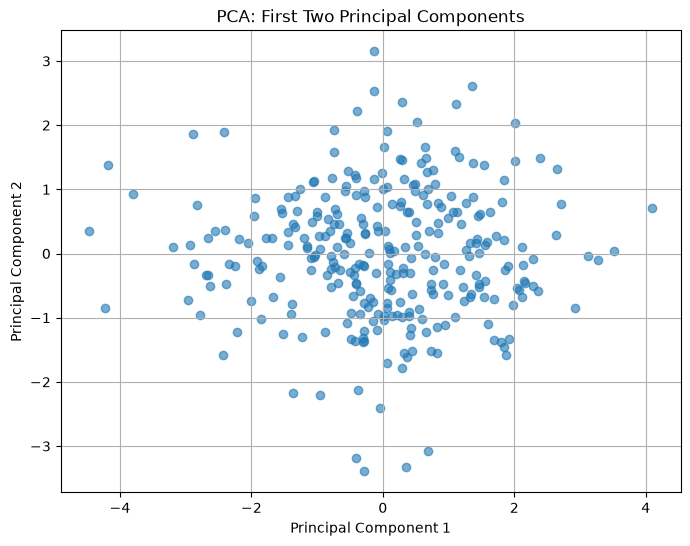

In [13]:
#Plot the 2D PCA projection
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components")
plt.grid(True)

plt.show()

In [14]:
#Compare with np.cov()
cov_numpy = np.cov(Xs.T)

print("\nOur covariance matrix:")
print(cov_matrix)

print("\nNumPy covariance matrix:")
print(cov_numpy)

print("\nCovariance matrices match:",
      np.allclose(cov_matrix, cov_numpy))


Our covariance matrix:
[[ 1.00334448  0.94407023  0.11046266  0.02645839]
 [ 0.94407023  1.00334448  0.05943294 -0.01137136]
 [ 0.11046266  0.05943294  1.00334448  0.03275312]
 [ 0.02645839 -0.01137136  0.03275312  1.00334448]]

NumPy covariance matrix:
[[ 1.00334448  0.94407023  0.11046266  0.02645839]
 [ 0.94407023  1.00334448  0.05943294 -0.01137136]
 [ 0.11046266  0.05943294  1.00334448  0.03275312]
 [ 0.02645839 -0.01137136  0.03275312  1.00334448]]

Covariance matrices match: True


In [15]:
# Compare eigenvalues
numpy_eigenvalues, _ = np.linalg.eigh(cov_numpy)

numpy_eigenvalues = numpy_eigenvalues[::-1]

print("\nOur eigenvalues:")
print(eigenvalues)

print("\nnp.cov() eigenvalues:")
print(numpy_eigenvalues)

print("\nEigenvalues match:",
      np.allclose(eigenvalues, numpy_eigenvalues))


Our eigenvalues:
[1.96269897 1.02966816 0.96381287 0.05719794]

np.cov() eigenvalues:
[1.96269897 1.02966816 0.96381287 0.05719794]

Eigenvalues match: True
